In [1]:
# cuda visible 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True

In [2]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
from DCGAN.encoder import Encoder
from DCGAN.reconstruction_generator import ReconstructionGenerator
from DCGAN.segmentation_generator import SegmentationGenerator
from DCGAN.refinement_network import RefinementNetwork
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss, EntropyLoss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [3]:
load_run = None
config_name = 'config.yaml'

In [4]:
if load_run:
    config_path = os.path.join(load_run,config_name)
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/dcgan'
    index_folder = get_version_folder(root)
    config = load_config(config_name)
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,config_name)
    save_config(config, config_target_path)




Config saved to cache/dcgan/5/config.yaml


In [5]:
channels = config['models']['channels']
z_shape = config['models']['z_shape']
z_dim = z_shape[0]
number_of_components = config['models']['number_of_components']

enc_block_depth = config['models']['enc']['block_depth']
enc_residual = config['models']['enc']['residual']
enc_use_norm = config['models']['enc']['use_norm']

gen_block_depth = config['models']['gen']['block_depth']
gen_residual = config['models']['gen']['residual']
gen_use_norm = config['models']['gen']['use_norm']
gen_vector_dim = config['models']['gen']['vector_dim']
gen_vectorizer_linear_layer_multipliers = config['models']['gen']['linear_layer_multipliers']
gen_degrees_of_freedom = config['models']['gen']['degrees_of_freedom']

seg_gen_block_depth = config['models']['segmentation_gen']['block_depth']
seg_gen_residual = config['models']['segmentation_gen']['residual']
seg_gen_use_norm = config['models']['segmentation_gen']['use_norm']

disc_block_depth = config['models']['disc']['block_depth']
disc_residual = config['models']['disc']['residual']
disc_use_norm = config['models']['disc']['use_norm']

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']
enc_feature_loss_weight = config['training']['enc']['enc_feature_loss_weight']

gen_lr = config['training']['gen']['gen_lr']

seg_gen_lr=  config['training']['segmentation_gen']['seg_gen_lr']
seg_gen_entropy_loss_weight = config['training']['segmentation_gen']['entropy_loss_weight']

n_critic = config['training']['disc']['n_critic']
disc_lr = config['training']['disc']['disc_lr']
disc_gp_loss_weight = config['training']['disc']['disc_gp_loss_weight']
disc_drift_loss_weight = config['training']['disc']['disc_drift_loss_weight']



save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

enc_path = os.path.join(index_folder,'enc.pth')
gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')
seg_gen_path = os.path.join(index_folder,'seg_gen.pth')
ref_net_path = os.path.join(index_folder,'ref_net.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

In [6]:

enc = Encoder(channels=channels,
              block_depth=enc_block_depth,
              z_dim=z_dim,
              residual=enc_residual,
              img_channels=3,
              use_norm=enc_use_norm).to(device)

gen = ReconstructionGenerator(channels=channels,
                z_dim=z_dim,                
                number_of_components=number_of_components,
                vector_dim=gen_vector_dim,
                vectorizer_linear_layer_multipliers=gen_vectorizer_linear_layer_multipliers,
                degrees_of_freedom=gen_degrees_of_freedom).to(device)

seg_gen = SegmentationGenerator(channels=channels,
                z_dim=z_dim,                
                block_depth=enc_block_depth,
                residual=gen_residual,
                number_of_components=number_of_components,
                use_norm=gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                      block_depth=disc_block_depth,
                      residual=disc_residual,
                      img_channels=3,
                      use_norm=disc_use_norm).to(device)


ref_network_channels = [64,64,64,32,16]
pos_embedding_dim = 4
ref_net_lr = 1e-3
ref_net= RefinementNetwork(in_channels=gen_vector_dim,
                           channels=ref_network_channels,
                           pos_embedding_dim=pos_embedding_dim).to(device)
                           



if load_run is not None:
    enc.load_state_dict(torch.load(enc_path))
    gen.load_state_dict(torch.load(gen_path))
    seg_gen.load_state_dict(torch.load(seg_gen_path))
    disc.load_state_dict(torch.load(disc_path))
    ref_net.load_state_dict(torch.load(ref_net_path))





enc_optim = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
gen_optim = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
seg_gen_optim = Adam(seg_gen.parameters(), lr=seg_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))
ref_net_optim = Adam(ref_net.parameters(), lr=ref_net_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


tensorboard_step = 0


In [7]:
import torch
def blend_seed_vectors(seed_vectors: torch.Tensor, probability_map: torch.Tensor) -> torch.Tensor:
    """
    Args:
        seed_vectors:    (B, n, d)    — batch of n seed vectors of dim d
        probability_map: (B, n, H, W) — batch of n-channel segmentation maps

    Returns:
        output: (B, d, H, W)
    """
    B, n, d = seed_vectors.shape
    B2, n2, H, W = probability_map.shape
    assert B == B2 and n == n2, "Batch size and number of seeds must match"

    # output[b, d, h, w] = sum_n( prob[b, n, h, w] * seed[b, n, d] )
    output = torch.einsum('bnhw,bnd->bdhw', probability_map, seed_vectors)
    return output

In [8]:
train_iter = iter(train_loader)


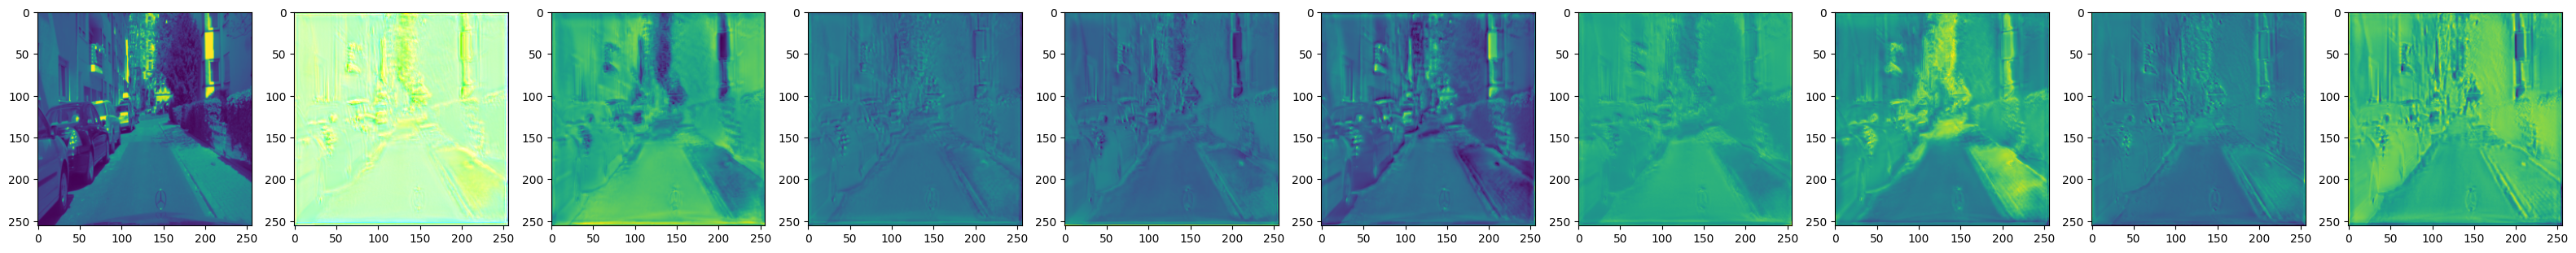

In [9]:
data ,_ = next(train_iter)
data = data.to(device)
with torch.no_grad():
    encoded_vector,skip = enc(data)
    seed_vectors = gen(encoded_vector)
    segmentation = seg_gen(encoded_vector, skip)
    num_classes = segmentation.shape[1]

    seed_map = blend_seed_vectors(seed_vectors, segmentation)
    reconstructed_image =ref_net(seed_map)

components = segmentation.shape[1]

fig,ax = plt.subplots(1,components+2,figsize=(40,40))
ax[0].imshow(data.cpu().numpy()[0,0])


reconstructed_image = scale_for_display(reconstructed_image)
ax[1].imshow(reconstructed_image.cpu()[0].permute(1,2,0).numpy())

for i in range(components):
    ax[i+2].imshow(segmentation.cpu().numpy()[0,i])

plt.show()

In [10]:
gp_loss_fn = GradientPenaltyLoss(weight=disc_gp_loss_weight)
reconstruction_loss_fn = WeightedMSELoss(weight=enc_reconstruction_loss_weight)
drift_loss_fn = DriftLoss(weight= disc_drift_loss_weight)
entropy_loss_fn = EntropyLoss(weight=seg_gen_entropy_loss_weight)

In [14]:
epochs = 100

for epoch in range(2, epochs):
    loop = tqdm(range(len(train_loader)))
    loop.set_description(f"Epoch {epoch}/{epochs}")
    for i in loop:
        # ─── DISCRIMINATOR ───────────────────────────────────────────────
        for _ in range(n_critic):
            try:
                real, _ = next(data_iter)
            except:
                data_iter = iter(train_loader)
                real, _ = next(data_iter)
            current_batch_size = real.size(0)
            real = real.to(device)
            disc_optim.zero_grad()

            disc_real = disc(real)
            disc_real_loss = -torch.mean(disc_real)


            # reconstructed from encoded real
            with torch.no_grad():
                encoded_vector,skip = enc(real)
                seed_vectors = gen(encoded_vector)
                segmentation = seg_gen(encoded_vector, skip)
                segmentation =  nn.Softmax(dim=1)(segmentation)
                num_classes = segmentation.shape[1]

                seed_map = blend_seed_vectors(seed_vectors, segmentation)
                reconstructed = ref_net(seed_map)

            disc_reconstructed = disc(reconstructed)
            disc_reconstructed_loss = torch.mean(disc_reconstructed)

            disc_adv_loss = disc_real_loss + disc_reconstructed_loss
            disc_gp_loss = gp_loss_fn(disc, real, reconstructed.detach())
            disc_drift_loss = drift_loss_fn(disc_real)

            disc_loss = disc_adv_loss + disc_gp_loss + disc_drift_loss
            disc_loss.backward()
            disc_optim.step()

      

        # ─── ENCODER + GENERATOR + SEG_GEN (reconstruction branch) ──────
        gen_optim.zero_grad()
        seg_gen_optim.zero_grad()
        enc_optim.zero_grad()

        encoded_vector,skip = enc(real)
        seed_vectors = gen(encoded_vector)
        segmentation = seg_gen(encoded_vector, skip)
        segmentation =  nn.Softmax(dim=1)(segmentation)

        num_classes = segmentation.shape[1]

        seed_map = blend_seed_vectors(seed_vectors, segmentation)
        reconstructed = ref_net(seed_map)

        disc_reconstructed, reconstructed_features = disc(reconstructed, return_features=True)
        with torch.no_grad():
            _, real_features = disc(real, return_features=True)

        enc_feature_loss = enc_feature_loss_weight * sum(
            F.l1_loss(f_enc, f_real.detach())
            for f_enc, f_real in zip(reconstructed_features, real_features)
        ) / len(reconstructed_features)

        enc_adv_loss = -torch.mean(disc_reconstructed)
        enc_reconstruction_loss = reconstruction_loss_fn(reconstructed, real)

        entropy_loss = entropy_loss_fn(segmentation)
        enc_loss = enc_adv_loss + enc_feature_loss + enc_reconstruction_loss + entropy_loss
        enc_loss.backward()
        enc_optim.step()
        gen_optim.step()
        seg_gen_optim.step()

        # ─── LOGGING ─────────────────────────────────────────────────────
        writer.add_scalar('Discriminator_Losses/Adversarial', disc_adv_loss.item(), tensorboard_step)
        writer.add_scalar('Discriminator_Losses/GP',          disc_gp_loss.item(),  tensorboard_step)
        writer.add_scalar('Discriminator_Losses/Drift',       disc_drift_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Adversarial',       enc_adv_loss.item(),  tensorboard_step)
        writer.add_scalar('Encoder_Losses/Reconstruction',    enc_reconstruction_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Feature',           enc_feature_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Entropy',           entropy_loss.item(), tensorboard_step)
        tensorboard_step += 1

        loop.set_postfix(
            loss_disc=disc_loss.item(),
            enc_loss=enc_loss.item()
        )

        if (i + 1) % save_itter == 0:
            torch.save(enc.state_dict(),     enc_path)
            torch.save(gen.state_dict(),     gen_path)
            torch.save(seg_gen.state_dict(), seg_gen_path)
            torch.save(disc.state_dict(),    disc_path)

            epoch_root = f'epoch_{epoch}'
            os.makedirs(os.path.join(samples_path, epoch_root), exist_ok=True)

            with torch.no_grad():
                encoded_vector,skip = enc(data)
                seed_vectors = gen(encoded_vector)
                segmentation = seg_gen(encoded_vector, skip)
                num_classes = segmentation.shape[1]

                seed_map = blend_seed_vectors(seed_vectors, segmentation)
                reconstructed = ref_net(seed_map)
                
            reconstructed = scale_for_display(reconstructed)
            real_disp    = scale_for_display(real)

            imgs_to_plot = torch.cat([real_disp[:4], reconstructed[:4]], dim=0)
            grid = vutils.make_grid(imgs_to_plot, nrow=4)
            vutils.save_image(grid, os.path.join(samples_path, epoch_root, f'{i}.png'))

Epoch 14/100:  67%|██████▋   | 841/1250 [51:48<25:11,  3.70s/it, enc_loss=315, loss_disc=-3.76]  


KeyboardInterrupt: 

In [ ]:
data ,_ = next(train_iter)
data = data.to(device)
with torch.no_grad():
    encoded_vector,skip = enc(data)
    seed_vectors = gen(encoded_vector)
    segmentation = seg_gen(encoded_vector, skip)
    num_classes = segmentation.shape[1]

    seed_map = blend_seed_vectors(seed_vectors, segmentation)
    reconstructed_image =ref_net(seed_map)

components = segmentation.shape[1]


columns = 2 
rows = components //2 +1
fig,ax = plt.subplots(rows,columns,figsize=(40,80))
ax[0,0].imshow(data.cpu().numpy()[0,0])
reconstructed_image = scale_for_display(reconstructed_image)
ax[0,1].imshow(reconstructed_image.cpu()[0].permute(1,2,0).numpy())

segmentation =  nn.Softmax(dim=1)(segmentation)
for i in range(components):
    ax[i//2 + 1,i%2].imshow(segmentation.cpu().numpy()[0,i])

plt.show()